# 8 &middot; Loading External Catalogs

`jax_fli` can ingest lightcones produced by other simulation suites and wrap them in the same
`Catalog` / `SphericalDensity` containers used throughout these tutorials. This notebook loads
three external products:

- **CosmoGrid** raw density lightcones (`load_cosmogrid_lc`)
- **CosmoGrid** Stage-3 forecast convergence maps (`load_cosmogrid_kappa`)
- **GowerStreet** density lightcones (`load_gowerstreet`)

Each loader returns a `Catalog` whose `.field[0]` is a stacked HEALPix map and whose
`.cosmology[0]` is the simulation's `jax_cosmo.Cosmology`.

> **Data location.** Set `SIM_ROOT` below to wherever you downloaded the suites. Paths/resolutions
> here are scaled down so the notebook runs on a laptop.

In [1]:
from pathlib import Path

import jax.numpy as jnp
import jax_fli as jfli
import numpy as np

# Point this at your local CosmoGrid / GowerStreet download.
SIM_ROOT = Path("/home/wassim/Projects/NBody/Simulations")

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## CosmoGrid density lightcone

CosmoGrid stores pre-computed shells as compressed `.npz`. `load_cosmogrid_lc` reads them into a
`Catalog`; `max_shells` and `ud_nside` cap how many shells we load and (down/up)-sample to.

In [2]:
cosmogrid = jfli.io.load_cosmogrid_lc(SIM_ROOT / "CosmoGrid/raw/cosmo_000001/run_0", max_shells=8, ud_nside=1024)
field = cosmogrid.field[0]
print(f"shape={field.shape}  nside={field.nside}  status={field.status}  unit={field.unit}")

shape=(8, 49152)  nside=64  status=FieldStatus.LIGHTCONE  unit=DensityUnit.COUNTS


In [3]:
cosmo = cosmogrid.cosmology[0]
for k in ("Omega_c", "Omega_b", "h", "sigma8", "n_s", "w0"):
    print(f"{k:8s}: {float(getattr(cosmo, k)):.4f}")

Omega_c : 0.2538
Omega_b : 0.0450
h       : 0.7300
sigma8  : 0.9000
n_s     : 0.9700
w0      : -1.1665


The shells are stored as particle **counts**; convert to `DENSITY` to view and to `OVERDENSITY` for the spectrum.

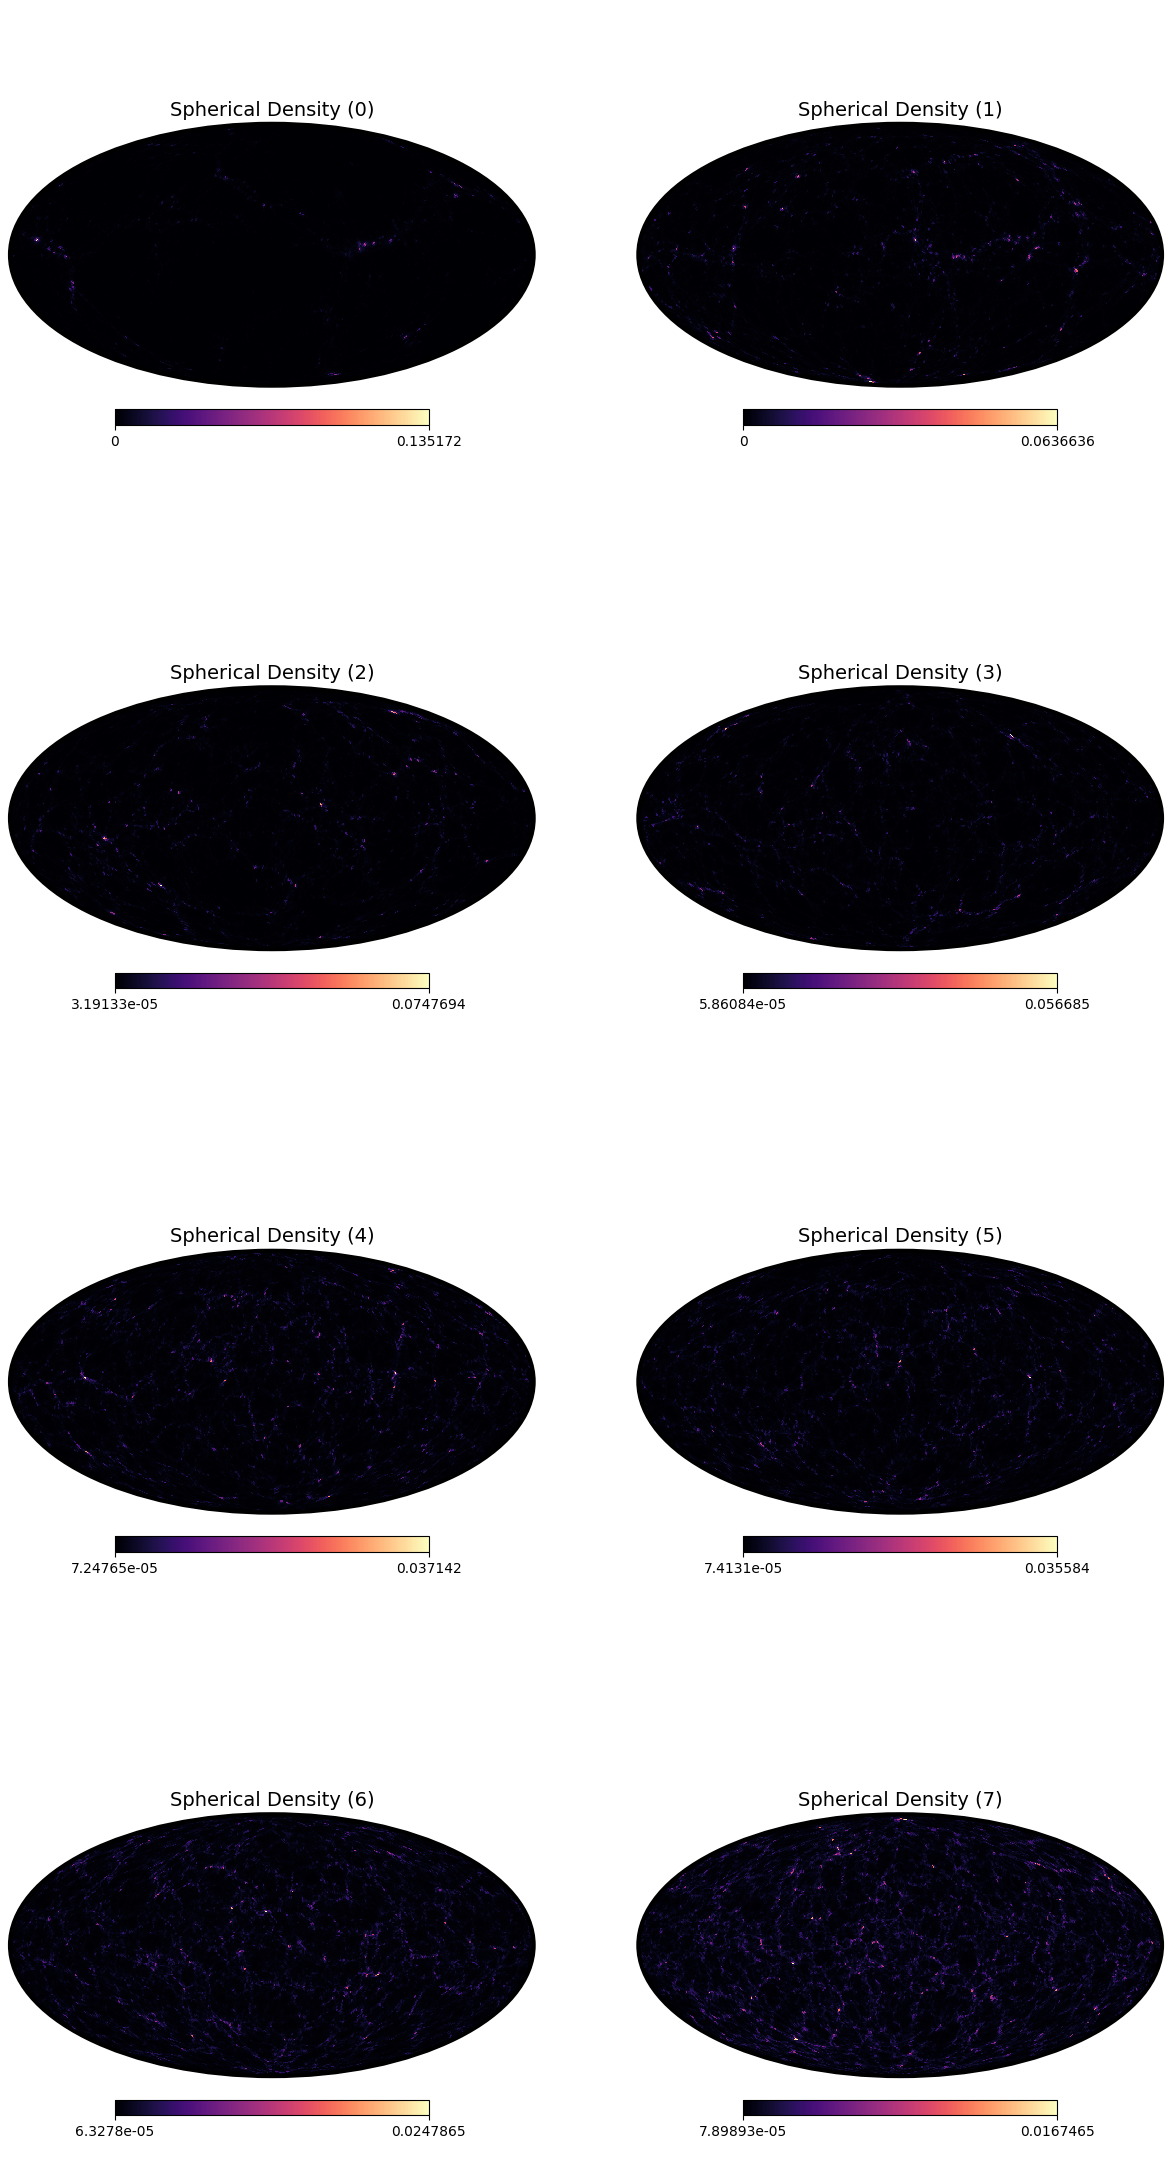

In [4]:
field.to(jfli.DensityUnit.DENSITY).apply_fn(jnp.log1p).show(ncols=2)

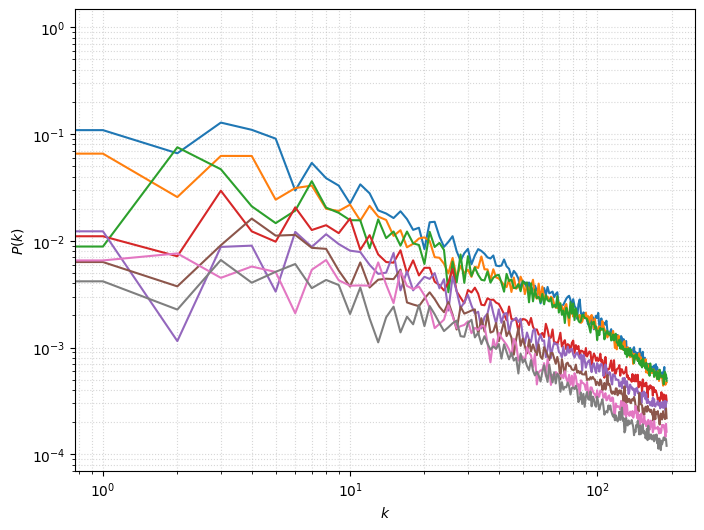

In [5]:
_ = field.to(jfli.units.OVERDENSITY).angular_cl().show()

## CosmoGrid Stage-3 convergence maps

`load_cosmogrid_kappa` reads the HDF5 Stage-3 forecast $\kappa$ maps (one per tomographic bin)
into a `SphericalKappaField`.

shape=(4, 3145728)  nside=512  unit=ConvergenceUnit.DIMENSIONLESS


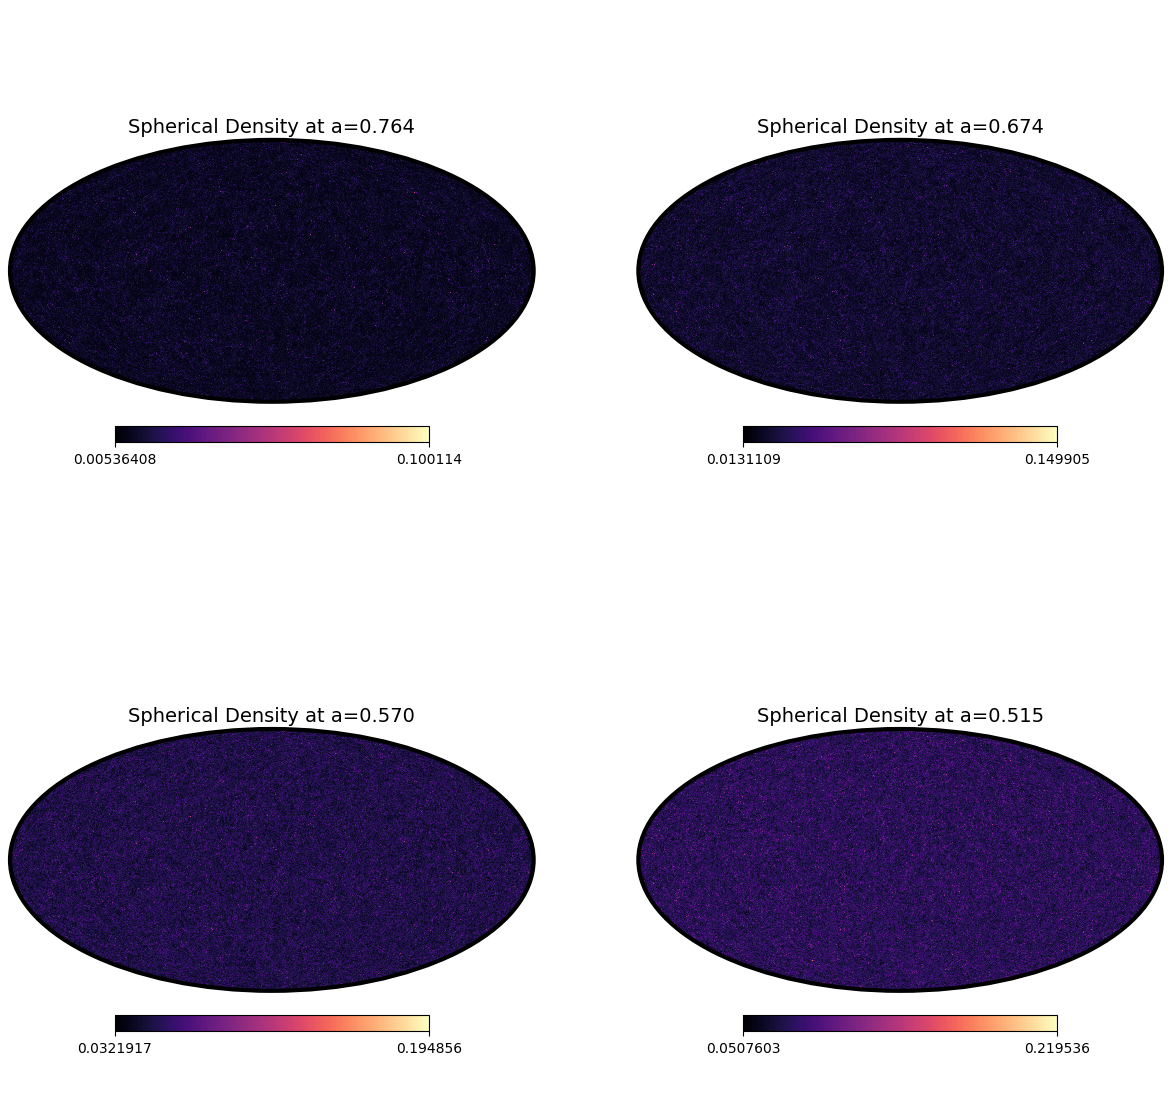

In [6]:
stage3 = jfli.io.load_cosmogrid_kappa(SIM_ROOT / "CosmoGrid/stage3_forecast/cosmo_000002/perm_0000")
kappa = stage3.field[0]
print(f"shape={kappa.shape}  nside={kappa.nside}  unit={kappa.unit}")
kappa.apply_fn(jnp.log1p).show(ncols=2)

## GowerStreet density lightcone

GowerStreet stores per-step `.npy` shells with a `control.par` (cosmology) and `z_values.txt`
(shell redshifts). `load_gowerstreet` assembles them; the native maps are high-resolution
(nside 2048), so we down-sample for the spectrum.

In [7]:
gowerstreet = jfli.io.load_gowerstreet(SIM_ROOT / "GowerStreet/sim00001", max_shells=8, ud_nside=None)
field_gs = gowerstreet.field[0]
print(f"shape={field_gs.shape}  nside={field_gs.nside}  unit={field_gs.unit}")
gs_cosmo = gowerstreet.cosmology[0]
for k in ("Omega_c", "Omega_b", "h", "sigma8", "n_s", "w0"):
    print(f"{k:8s}: {float(getattr(gs_cosmo, k)):.4f}")

[(100,), (100,), (100,), (100,), (100,)]
[(8,), (8,), (8,), (8,), (100,)]


shape=(8, 50331648)  nside=2048  unit=DensityUnit.COUNTS
Omega_c : 0.2410
Omega_b : 0.0490
h       : 0.6674
sigma8  : 0.7658
n_s     : 0.9497
w0      : -1.0089


In [8]:
print("scale factors   :", np.asarray(field_gs.scale_factors).ravel())
print("comoving centers:", np.asarray(field_gs.comoving_centers).ravel().round(0))
print("shell widths    :", np.asarray(field_gs.density_width).ravel().round(0))

scale factors   : [0.9286073  0.93796223 0.94736534 0.9568174  0.96631944 0.9758725
 0.98547703 0.9951343 ]
comoving centers: [121. 105.  90.  75.  59.  44.  29.  15.]
shell widths    : [211. 180. 149. 119.  89.  59.  29.  -0.]


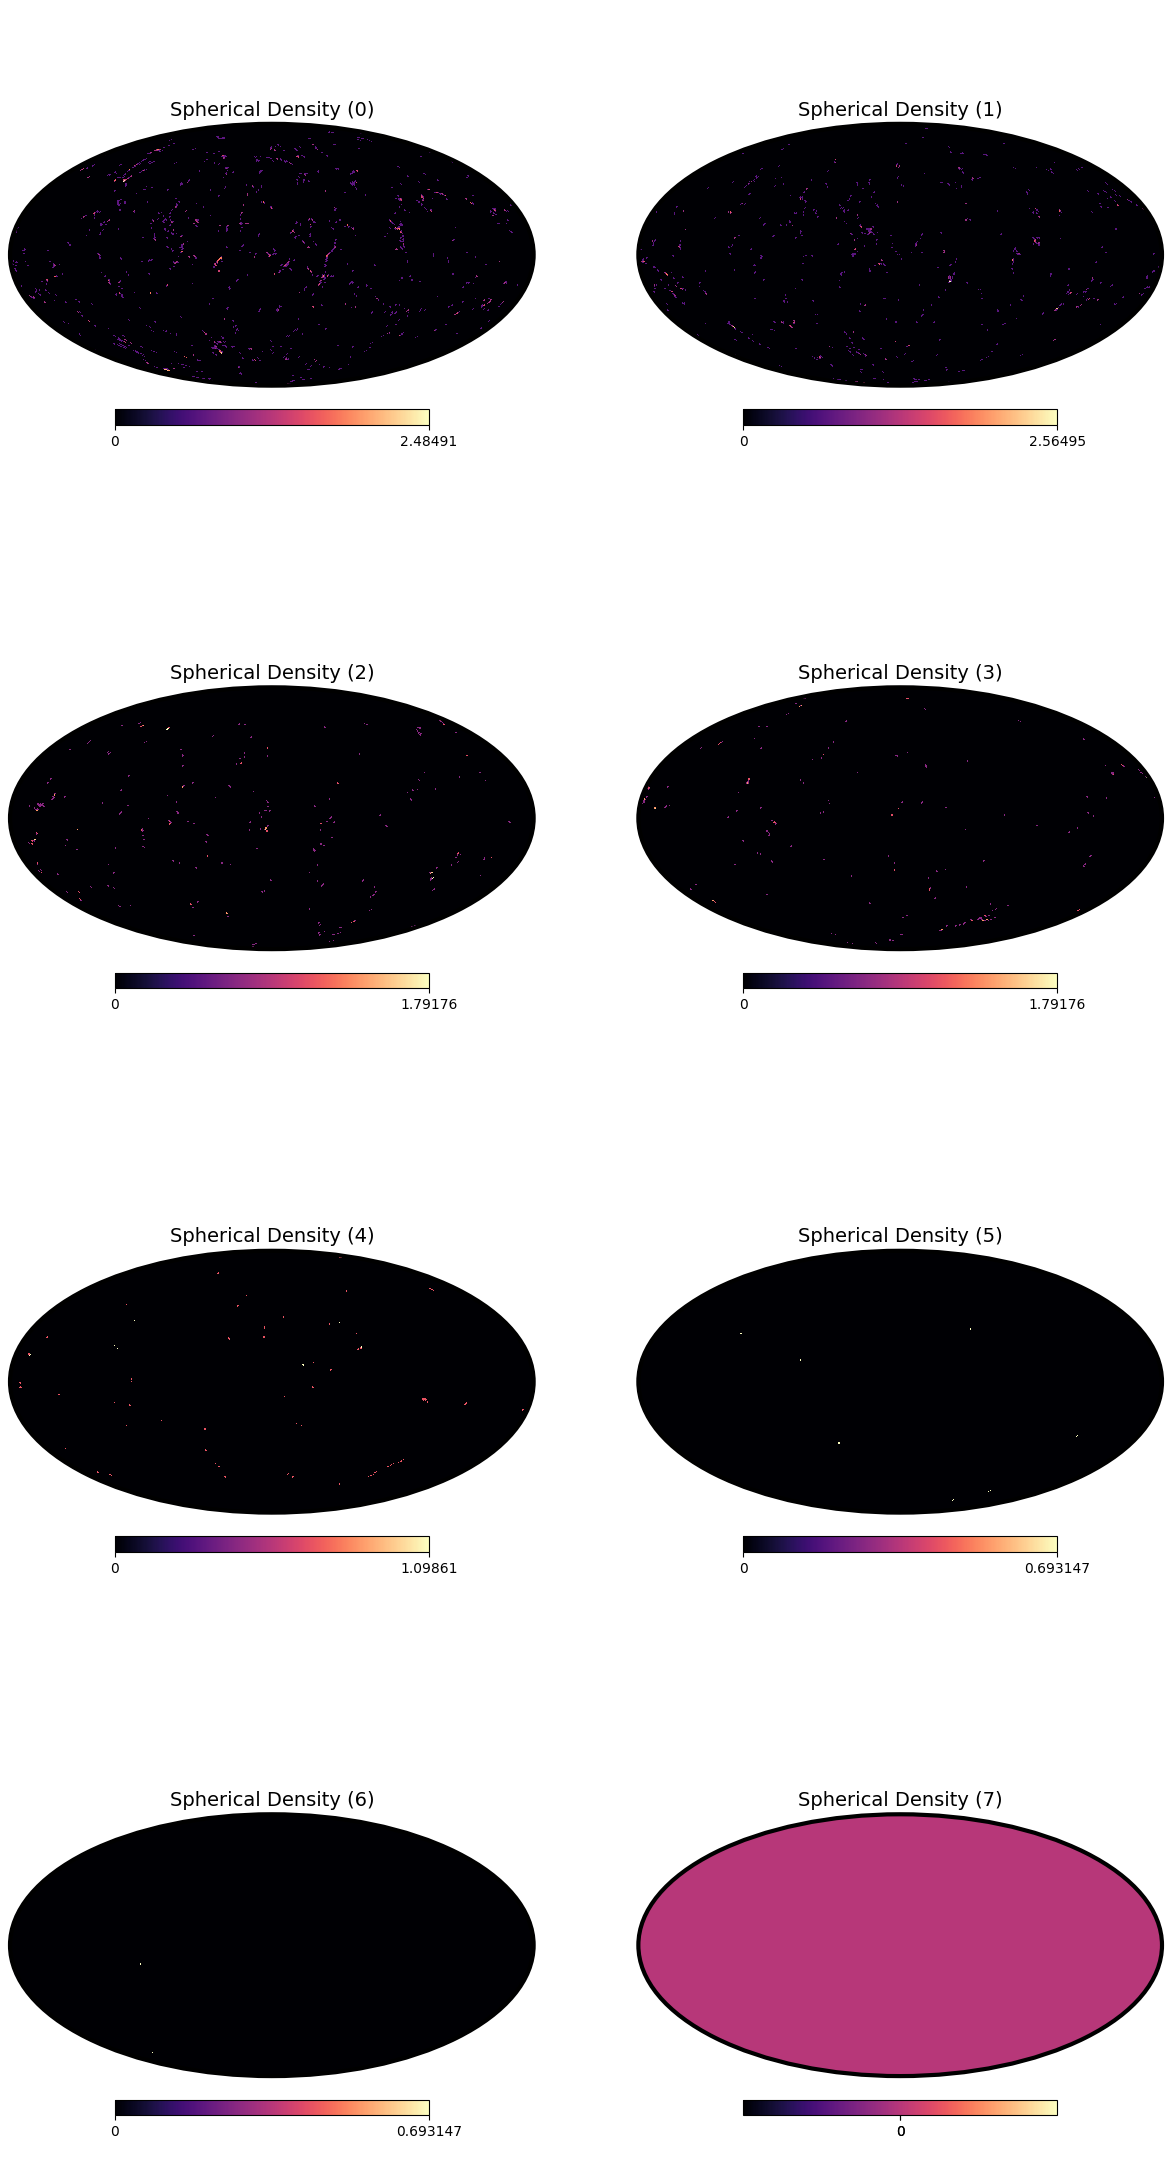

In [9]:
# Shells are sparse particle counts on a fine (nside 2048) grid; down-sample to view.
field_gs.ud_sample(512).apply_fn(jnp.log1p).show(ncols=2)

A power spectrum, shown as $D_\ell=\ell(\ell+1)C_\ell/2\pi$. We down-sample to nside 256,
convert to overdensity per shell (`per_plane`), and replace any non-finite pixels from empty
shells with `nan_to_num` before estimating $C_\ell$.

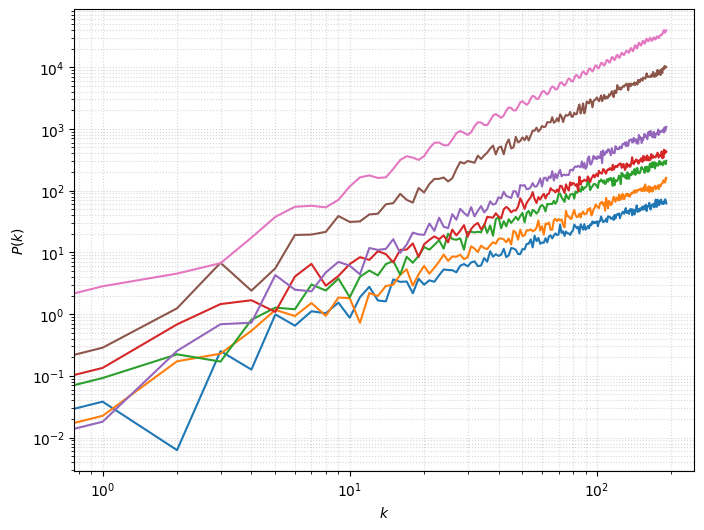

In [10]:
overdensity = field_gs.ud_sample(512).to(jfli.units.OVERDENSITY, normalization="per_plane").apply_fn(jnp.nan_to_num)
cl = overdensity.angular_cl(method="healpy")
cl = cl.apply_fn(lambda x: x * cl.wavenumber * (cl.wavenumber + 1) / (2 * np.pi))
_ = cl.show()

## Next

[09 &middot; Multi-host PM](09-multi-host-pm.md) launches a large simulation across nodes and
validates the resulting convergence against a CosmoGrid reference loaded exactly as above.